# Phase 2: 10-Class MNIST Classification — K-Nearest Neighbors
## Pipeline: Data Loading → Preprocessing → PCA → Training → CV Tuning → Learning Curves → Evaluation

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from sklearn.decomposition import PCA
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [2]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
KNN_K_GRID = [1, 3, 5, 7, 9]
DEFAULT_K = 5

## 3. Data Loading & Preprocessing

In [3]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


## 4. Feature Extraction (Flatten → Scaler → PCA)

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} → {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 → 324 components (0.9503 var)


## 5. Utility Functions

In [5]:
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def k_fold_split(X, y, k=5, seed=42):
    rng = np.random.RandomState(seed)
    idx = np.arange(len(y)); rng.shuffle(idx)
    fold_sz = len(y) // k
    folds = []
    for i in range(k):
        s, e = i*fold_sz, (i+1)*fold_sz if i < k-1 else len(y)
        v = idx[s:e]; t = np.concatenate([idx[:s], idx[e:]])
        folds.append((t, v))
    return folds

def cross_validate(model_cls, params, X, y, k=5):
    folds = k_fold_split(X, y, k=k)
    accs = []
    for fi, (ti, vi) in enumerate(folds):
        m = model_cls(**params); m.fit(X[ti], y[ti])
        acc = compute_accuracy(y[vi], m.predict(X[vi]))
        accs.append(acc)
        print(f"  Fold {fi+1}/{k}: {acc:.4f}")
    mean_acc = np.mean(accs)
    print(f"  Mean CV: {mean_acc:.4f}")
    return mean_acc

def plot_learning_curve(model_cls, params, X_tr, y_tr, X_vl, y_vl, fracs, title):
    tr_a, vl_a, szs = [], [], []
    n = len(y_tr)
    for f in fracs:
        sz = max(int(n*f), 10); szs.append(sz)
        idx = np.random.choice(n, sz, replace=False)
        m = model_cls(**params); m.fit(X_tr[idx], y_tr[idx])
        tr_a.append(compute_accuracy(y_tr[idx], m.predict(X_tr[idx])))
        vl_a.append(compute_accuracy(y_vl, m.predict(X_vl)))
    plt.figure(figsize=(8,5))
    plt.plot(szs, tr_a, 'o-', label='Train', color='#2ecc71')
    plt.plot(szs, vl_a, 's-', label='Val', color='#e74c3c')
    plt.fill_between(szs, tr_a, vl_a, alpha=0.15, color='gray')
    plt.xlabel('Training Size'); plt.ylabel('Accuracy')
    plt.title(title, fontweight='bold'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def evaluate_model(model, X_ts, y_ts, name):
    preds = model.predict(X_ts)
    acc = compute_accuracy(y_ts, preds)
    print(f"\n{'='*70}\n{name} — Test Acc: {acc:.4f} ({acc*100:.2f}%)\n{'='*70}")
    print(classification_report(y_ts, preds, target_names=[f'Digit {i}' for i in range(NUM_CLASSES)]))
    cm = confusion_matrix(y_ts, preds)
    plt.figure(figsize=(8,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.title(f'{name}\nTest Acc: {acc:.4f}', fontweight='bold')
    plt.tight_layout(); plt.show()
    return acc

## 6. KNN Model

Uses **Euclidean distance** and **majority voting**.

In [6]:
class KNearestNeighbors:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train, self.y_train = X, y
        return self

    def _predict_single(self, x):
        dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        k_labels = self.y_train[np.argsort(dists)[:self.k]]
        return np.argmax(np.bincount(k_labels, minlength=10))

    def predict(self, X):
        return np.array([self._predict_single(X[i]) for i in tqdm(range(len(X)), desc='KNN')])

## 7. Baseline Training

BASELINE KNN (k=5)


KNN: 100%|██████████| 9470/9470 [1:13:28<00:00,  2.15it/s]



KNN Baseline (k=5) — Test Acc: 0.9407 (94.07%)
                 precision     recall   f1-score    support

        Digit 0       0.96       0.98       0.97        947
        Digit 1       0.95       0.99       0.97        947
        Digit 2       0.95       0.93       0.94        947
        Digit 3       0.92       0.94       0.93        947
        Digit 4       0.95       0.94       0.94        947
        Digit 5       0.93       0.93       0.93        947
        Digit 6       0.94       0.98       0.96        947
        Digit 7       0.93       0.92       0.92        947
        Digit 8       0.97       0.88       0.92        947
        Digit 9       0.91       0.92       0.91        947

       accuracy                             0.94       9470
      macro avg       0.94       0.94       0.94       9470
   weighted avg       0.94       0.94       0.94       9470



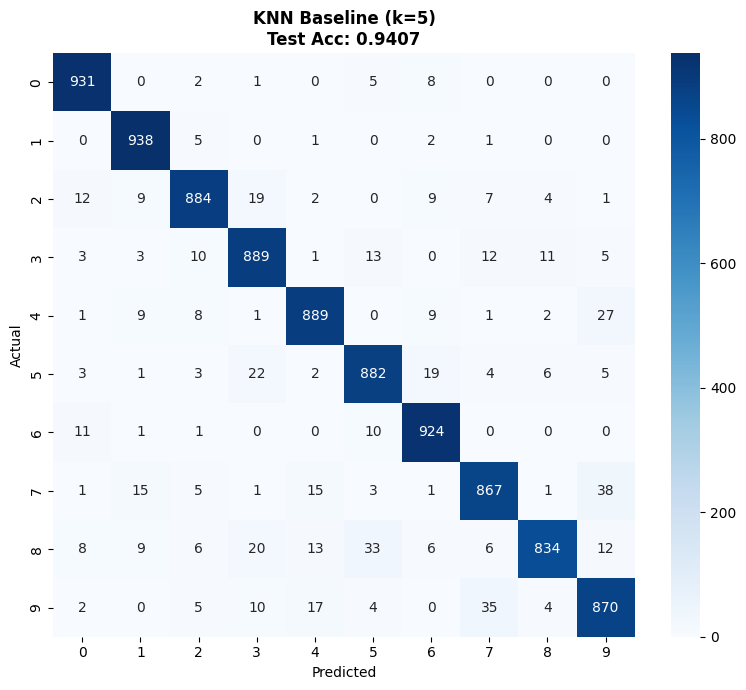

In [7]:
print("BASELINE KNN (k=5)")
knn_base = KNearestNeighbors(k=DEFAULT_K)
knn_base.fit(X_train_pca, y_train)
base_acc = evaluate_model(knn_base, X_test_pca, y_test, "KNN Baseline (k=5)")

## 8. Hyperparameter Tuning (K-Fold CV)


K=1


KNN: 100%|██████████| 8838/8838 [44:11<00:00,  3.33it/s] 


  Fold 1/5: 0.9432


KNN: 100%|██████████| 8838/8838 [36:56<00:00,  3.99it/s]  


  Fold 2/5: 0.9409


...

  Fold 3/5: 0.9415


KNN: 100%|██████████| 8838/8838 [09:15<00:00, 15.90it/s]


  Fold 4/5: 0.9416


KNN: 100%|██████████| 8838/8838 [09:16<00:00, 15.87it/s]


  Fold 5/5: 0.9383
  Mean CV: 0.9397

Best K=3 (CV=0.9439)


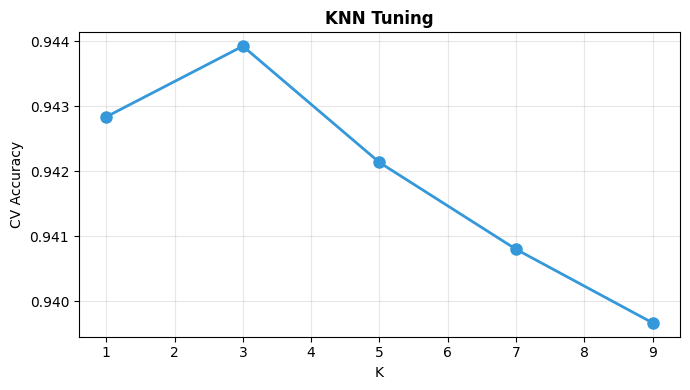

In [8]:
best_acc, best_k = 0, DEFAULT_K
cv_res = []
for kv in KNN_K_GRID:
    print(f"\nK={kv}")
    a = cross_validate(KNearestNeighbors, {'k': kv}, X_train_pca, y_train, k=K_FOLDS)
    cv_res.append((kv, a))
    if a > best_acc: best_acc, best_k = a, kv
print(f"\nBest K={best_k} (CV={best_acc:.4f})")

ks, accs = zip(*cv_res)
plt.figure(figsize=(7,4))
plt.plot(ks, accs, 'o-', color='#3498db', lw=2, ms=8)
plt.xlabel('K'); plt.ylabel('CV Accuracy')
plt.title('KNN Tuning', fontweight='bold'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

KNN: 100%|██████████| 9470/9470 [11:11<00:00, 14.10it/s]



KNN Tuned (k=3) — Test Acc: 0.9428 (94.28%)
                 precision     recall   f1-score    support

        Digit 0       0.94       0.99       0.96        947
        Digit 1       0.96       0.99       0.98        947
        Digit 2       0.95       0.93       0.94        947
        Digit 3       0.92       0.94       0.93        947
        Digit 4       0.95       0.94       0.94        947
        Digit 5       0.94       0.93       0.93        947
        Digit 6       0.95       0.97       0.96        947
        Digit 7       0.94       0.92       0.93        947
        Digit 8       0.96       0.88       0.92        947
        Digit 9       0.92       0.92       0.92        947

       accuracy                             0.94       9470
      macro avg       0.94       0.94       0.94       9470
   weighted avg       0.94       0.94       0.94       9470



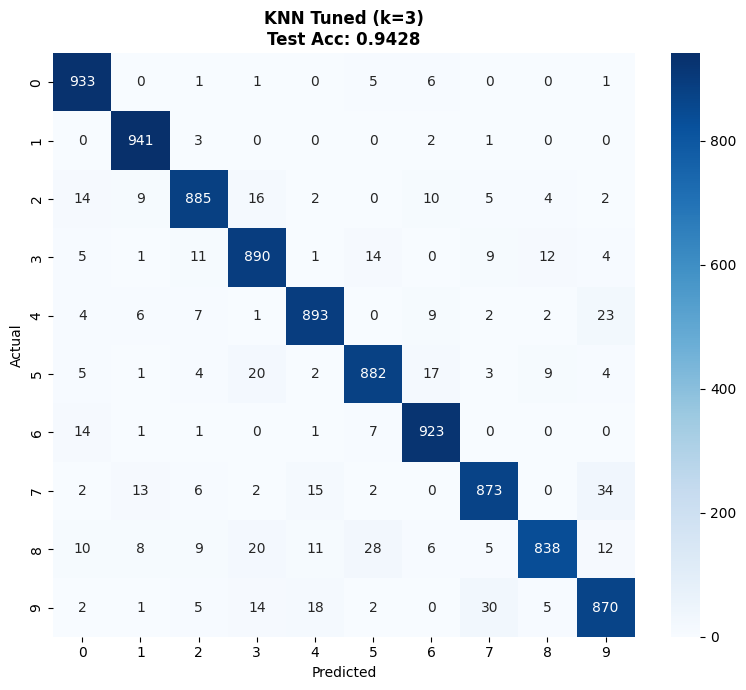

In [9]:
knn_tuned = KNearestNeighbors(k=best_k)
knn_tuned.fit(X_train_pca, y_train)
tuned_acc = evaluate_model(knn_tuned, X_test_pca, y_test, f"KNN Tuned (k={best_k})")

## 9. Learning Curve

KNN: 100%|██████████| 9470/9470 [12:08<00:00, 13.00it/s]


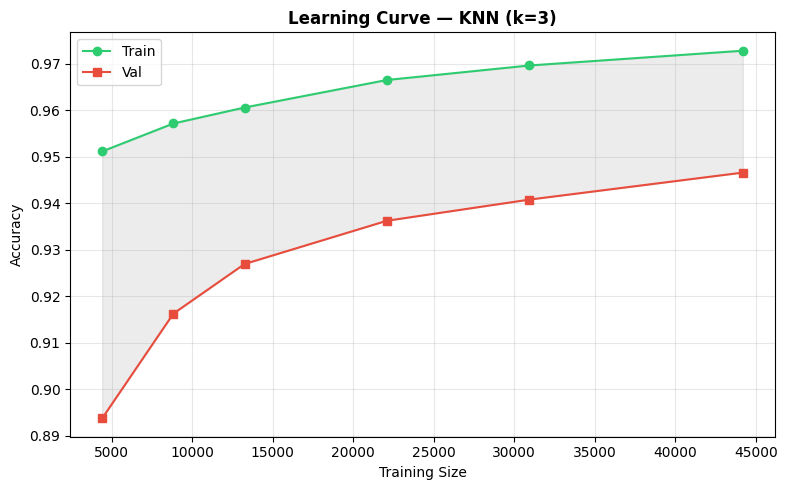

In [10]:
plot_learning_curve(KNearestNeighbors, {'k': best_k}, X_train_pca, y_train,
                    X_val_pca, y_val, LC_FRACTIONS, f"Learning Curve — KNN (k={best_k})")

## 10. Summary

**Analysis**: KNN with small k → high variance (train≈100%, val lower).
Increasing k reduces variance but increases bias.